# Time varying signals

In contrast to static response, time-varying response can also be the output of your sensor and correspond to all the situations when the amplitude of a signal varies with time.

In this activity we will explore how to extract features from these signals that may relate with the applied stimulus.

# Time domain features
Some of the time domain features include:
 - mean and median, 
 - standard deviation and variance
 - root mean square (RMS)
 - peak-to-peak
 - skewness

  <img src="img/timefeatures1.png" width="900"/>

***Exercise:*** Plot the signals and compute the following time-domain features:
- Mean and Median;
- Standard Deviation;
- Root Mean Square;
- Maximum, Minimum, and Peak-to-peak;
- Skewness;

In [111]:
# Generate mockup data to analyze
import numpy as np

tstop = 30
time = np.linspace(0,tstop,tstop*1000)
dt=time[1]-time[0]

def gensignalA(t):
    ff = 5  
    ff2 = 0.1
    return np.cos(2*np.pi*ff2*t)*(np.cos(2*np.pi*(ff) * t + .0*np.random.random(len(t))) + 0.2*np.random.normal(loc=0, scale=0.7, size=len(t)))

def gensignalB(t):
    brownian_noise = np.cumsum(np.random.normal(loc=0, scale=0.7*np.sqrt(t[1]-t[0]), size=len(t)))
    ff = 5  
    ff2 = 0.1
    return np.cos(2*np.pi*ff2*t)*np.cos(2*np.pi*(ff) * (t-0.1)) + 1*brownian_noise

signalA = gensignalA(time)
signalB = gensignalB(time)

In [300]:
# import matplotlib.pyplot as plt
# from scipy.stats import skew


## Frequency-domain features

***Exercise:*** Compute the Fourier transform and the Power spectral density. Compare both. Characterize the type of noise you find in **signalB**.

In [301]:
# from scipy.signal import welch

***Exercise:*** For the same signal compute the Fourier transform and extract some frequency domain features:
- Fundamental Frequency;
- Spectral Centroid;
- Spectral Bandwidth;
- Spectral Entropy;

Below we have auxiliary functions that provide these features from FFT Magnitude or PSD. Take a look if they are ok and then utilize them to compute the features.
Comment the results, are they expected?

In [302]:
## auxiliary functions  -  take a look to understand them
import scipy.signal

### Feature extraction from magnitude ###
def compute_fundamental_frequency_magnitude(sig, fs):
    N = len(sig)
    yf = np.fft.fft(sig)
    xf = np.linspace(0.0, fs / 2, N // 2)
    magnitudes = 2.0 / N * np.abs(yf[:N // 2])
    peaks, _ = scipy.signal.find_peaks(magnitudes)
    fundamental_freq = xf[peaks][0]  # assuming the first peak is the fundamental frequency
    return fundamental_freq


def compute_spectral_bandwidth_magnitude(signal, fs):
    magnitudes = np.abs(np.fft.rfft(signal))
    length = len(signal)
    frequencies = np.abs(np.fft.fftfreq(length, 1.0/fs)[:length//2+1])
    spectral_centroid = np.sum(frequencies * magnitudes) / np.sum(magnitudes)
    spectral_bandwidth = np.sqrt(np.sum(((frequencies - spectral_centroid) ** 2) * magnitudes) / np.sum(magnitudes))
    return spectral_bandwidth

def compute_spectral_centroid_magnitude(signal, fs):
    magnitudes = np.abs(np.fft.rfft(signal))
    length = len(signal)
    frequencies = np.abs(np.fft.fftfreq(length, 1.0/fs)[:length//2+1])
    spectral_centroid = np.sum(frequencies * magnitudes) / np.sum(magnitudes)
    return spectral_centroid

def compute_spectral_entropy_magnitude(signal, fs):
    eps = np.finfo(np.float32).eps
    magnitude = np.abs(np.fft.fft(signal)) ** 2
    magnitude= magnitude[:len(signal) // 2]
    magnitude /= magnitude.sum() + eps  # Normalize
    spectral_entropy = -np.sum(magnitude * np.log2(magnitude + eps))
    return spectral_entropy


### Feature extraction from Power spectral density
def compute_fundamental_frequency_PSD(signal, fs):

    f, Pxx = scipy.signal.welch(signal, fs, nperseg=1024)
    peaks, _ = scipy.signal.find_peaks(Pxx)
    fundamental_freq = f[peaks][0]  # assuming the first peak is the fundamental frequency
    return fundamental_freq


def compute_spectral_bandwidth_PSD(signal, fs):
    f, Pxx = scipy.signal.welch(signal, fs, nperseg=1024)
    spectral_centroid = np.sum(f * Pxx) / np.sum(Pxx)
    spectral_bandwidth = np.sqrt(np.sum(((f - spectral_centroid) ** 2) * Pxx) / np.sum(Pxx))
    return spectral_bandwidth

def compute_spectral_centroid_PSD(signal, fs):
    f, Pxx = scipy.signal.welch(signal, fs, nperseg=1024)
    spectral_centroid = np.sum(f * Pxx) / np.sum(Pxx)
    
    return spectral_centroid

def compute_spectral_entropy_PSD(signal, fs):
    eps = np.finfo(np.float32).eps
    f, Pxx = scipy.signal.welch(signal, fs, nperseg=1024)
    Pxx /= Pxx.sum() + eps  # Normalize
    spectral_entropy = -np.sum(Pxx * np.log2(Pxx + eps))
    return spectral_entropy


In [175]:
fs = 1 / (time[1] - time[0])

# signal = signalA
# print('Signal A')
# print(f"Spectral Centroid (Magnitude) = {compute_spectral_centroid_magnitude(signal, fs=1/dt):.3f} Hz")
# print(f"Spectral Centroid (PSD) = {compute_spectral_centroid_PSD(signal, fs=1/dt):.3f} Hz")

# print(f"Fundamental Frequency (Magnitude) = {compute_fundamental_frequency_magnitude(signal, fs=1/dt):.3f} Hz")
# print(f"Fundamental Frequency (PSD) = {compute_fundamental_frequency_PSD(signal, fs=1/dt):.3f} Hz")

# print(f"Spectral Bandwidth (Magnitude) = {compute_spectral_bandwidth_magnitude(signal, fs=1/dt):.3f} Hz")
# print(f"Spectral Bandwidth (PSD) = {compute_spectral_bandwidth_PSD(signal, fs=1/dt):.3f} Hz")

# print(f"Spectral Entropy (Magnitude) = {compute_spectral_entropy_magnitude(signal, fs=1/dt):.3f}")
# print(f"Spectral Entropy (PSD) = {compute_spectral_entropy_PSD(signal, fs=1/dt):.3f}")
# print('\n')

print('Signal B')
signal = signalB
print(f"Spectral Centroid (Magnitude) = {compute_spectral_centroid_magnitude(signal, fs=1/dt):.3f} Hz")
print(f"Spectral Centroid (PSD) = {compute_spectral_centroid_PSD(signal, fs=1/dt):.3f} Hz")

print(f"Fundamental Frequency (Magnitude) = {compute_fundamental_frequency_magnitude(signal, fs=1/dt):.3f} Hz")
print(f"Fundamental Frequency (PSD) = {compute_fundamental_frequency_PSD(signal, fs=1/dt):.3f} Hz")

print(f"Spectral Bandwidth (Magnitude) = {compute_spectral_bandwidth_magnitude(signal, fs=1/dt):.3f} Hz")
print(f"Spectral Bandwidth (PSD) = {compute_spectral_bandwidth_PSD(signal, fs=1/dt):.3f} Hz")

print(f"Spectral Entropy (Magnitude) = {compute_spectral_entropy_magnitude(signal, fs=1/dt):.3f}")
print(f"Spectral Entropy (PSD) = {compute_spectral_entropy_PSD(signal, fs=1/dt):.3f}")


Signal B
Spectral Centroid (Magnitude) = 40.622 Hz
Spectral Centroid (PSD) = 4.838 Hz
Fundamental Frequency (Magnitude) = 0.233 Hz
Fundamental Frequency (PSD) = 0.977 Hz
Spectral Bandwidth (Magnitude) = 95.924 Hz
Spectral Bandwidth (PSD) = 7.395 Hz
Spectral Entropy (Magnitude) = 1.268
Spectral Entropy (PSD) = 2.037


## Statistical and correlation features

***Exercise:*** Compute the correlation between signalA and signalB try to understand if they are correlated and if there is any lag between them. Comment the results


## Time-Frequency Analysis

***Demonstration:*** Focusing on signalC, use time-frequency analysis tools to construct a spectrogram. Do that using:
1. Short-time Fourier Transform;
2. Wavelet analysis;

Comment the results.

In [192]:
def s(t):
    f1=.5
    f2=2
    f3=4
    f4=1
    f0=0.5
    return (3*np.sin(2*np.pi*f0*t) # Fundamental frequency
            +5*np.exp(-(t-10)**2*0.5)*np.sin(2*np.pi*f1*t) # Added burst at t = 10, with amplitude = 5
            + 5*np.exp(-(t-30)**2*0.5)*np.sin(2*np.pi*f2*t) # Burst at t = 10, amp = 5
             + 5*np.exp(-(t-80)**2*0.5)*np.sin(2*np.pi*f4*t) #Burst at t = 80, amp = 5
             +10*np.exp(-(t-50)**2*3)*np.sin(2*np.pi*f3*t) # Burst at t = 50, amp = 10
              )* np.exp(-t/600) + np.random.random(len(t)) # Added noise


fs = 30  # Sampling frequency
t_f  = 100
t = np.linspace(0, t_f, fs*t_f)

signalC = s(t)

In [303]:
# !pip install pywt

c:\Users\Catarina\.conda\envs\underwater\Lib\site-packages\pywt\_cwt.py:113: FutureWarning: Wavelets from the family cmor, without parameters specified in the name are deprecated. The name should follow the format cmorB-C, where B and C are floats representing the bandwidth frequency and center frequency, respectively (example, for backward compatibility: cmor = cmor1.0-0.5).
  wavelet = DiscreteContinuousWavelet(wavelet)


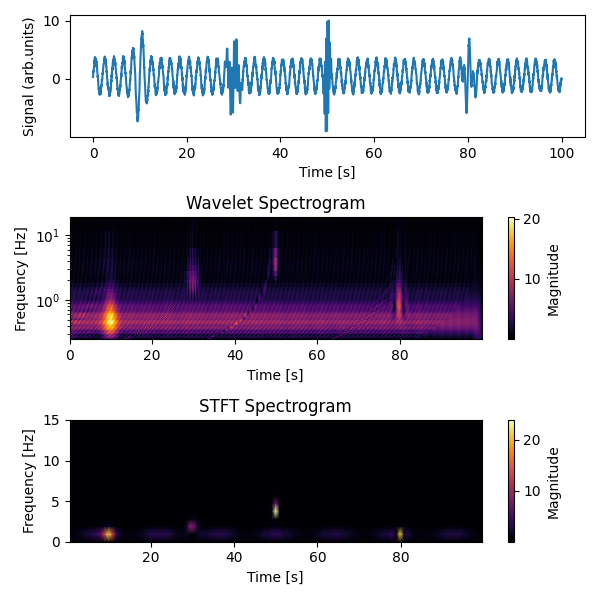

In [ ]:
from scipy.signal import spectrogram
from scipy import signal
import pywt
import matplotlib.pyplot as plt

# widths = np.arange(1,61) # Widths to use for the CWT
# cwt_result = cwt(signal, ricker, widths)
t = np.arange(len(signalC)) / fs

coef, freqs = pywt.cwt(signalC, np.arange(1, 61), 'cmor',
                       sampling_period=1/fs)

# Plotting

fig,ax = plt.subplots(3,1,figsize=(6, 6))

ax[0].plot(t,signalC)
ax[0].set_xlabel('Time [s]')
ax[0].set_ylabel('Signal (arb.units)')

im = ax[1].pcolor(t, freqs, np.abs(coef), cmap='inferno')

#im = ax[1].imshow(np.abs(cwt_result), extent=[t[0], t[-1], widths[-1], widths[0]], origin='upper', cmap='jet', aspect='auto', vmax=np.max(cwt_result), vmin=np.min(cwt_result))
plt.colorbar(im,ax=ax[1],label='Magnitude')
ax[1].set_xlabel('Time [s]')
ax[1].set_ylabel('Frequency [Hz]')
ax[1].set_title('Wavelet Spectrogram')
ax[1].set_yscale('log')


f, t, Sxx = spectrogram(signalC, fs,nperseg=32)
im = ax[2].pcolormesh(t, f, (Sxx), shading='gouraud', cmap='inferno')
plt.colorbar(im,label='Magnitude')
ax[2].set_xlabel('Time [s]')
ax[2].set_ylabel('Frequency [Hz]')
ax[2].set_title('STFT Spectrogram')

fig.tight_layout()

## Aliasing

***Demonstration:*** Effect of aliasing in the spectral signature.

c:\Users\Catarina\.conda\envs\underwater\Lib\site-packages\scipy\signal\_spectral_py.py:790: UserWarning: nperseg = 1024 is greater than input length  = 1000, using nperseg = 1000
  freqs, _, Pxy = _spectral_helper(x, y, fs, window, nperseg, noverlap,
c:\Users\Catarina\.conda\envs\underwater\Lib\site-packages\scipy\signal\_spectral_py.py:790: UserWarning: nperseg = 1024 is greater than input length  = 50, using nperseg = 50
  freqs, _, Pxy = _spectral_helper(x, y, fs, window, nperseg, noverlap,
c:\Users\Catarina\.conda\envs\underwater\Lib\site-packages\scipy\signal\_spectral_py.py:790: UserWarning: nperseg = 1024 is greater than input length  = 8, using nperseg = 8
  freqs, _, Pxy = _spectral_helper(x, y, fs, window, nperseg, noverlap,


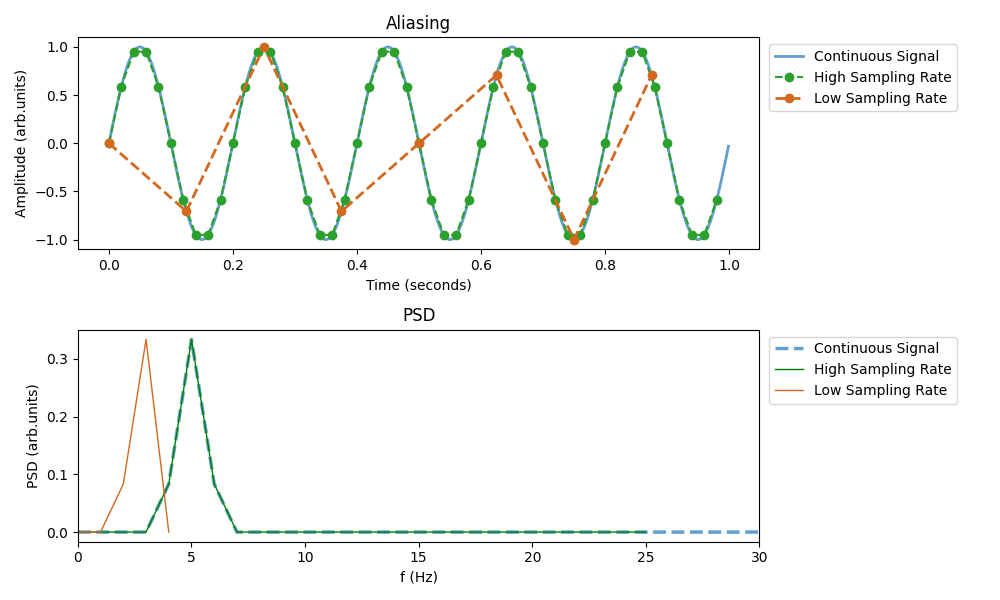

In [250]:
import scipy.signal
# Parameters for the sine wave
frequency_of_signal = 5  # frequency of the sine wave in Hz
duration = 1  # duration of the signal in seconds

# Generate a time array for the continuous signal
t_continuous = np.linspace(0, duration, 1000, endpoint=False)  # High resolution for continuous representation
signal_continuous = np.sin(2 * np.pi * frequency_of_signal * t_continuous)

# Sampling the signal at two different rates
sampling_rate_high = 50  # High sampling rate (above Nyquist rate)
sampling_rate_low = 8  # Low sampling rate (below Nyquist rate)

# Generate sampled time arrays
t_sampled_high = np.linspace(0, duration, sampling_rate_high * duration, endpoint=False)
t_sampled_low = np.linspace(0, duration, sampling_rate_low * duration, endpoint=False)

# Sample the continuous signal
signal_sampled_high = np.sin(2 * np.pi * frequency_of_signal * t_sampled_high)
signal_sampled_low = np.sin(2 * np.pi * frequency_of_signal * t_sampled_low)

# Plotting
fig,ax = plt.subplots(2,1, figsize = (10,6))

#Original Signal
ax[0].plot(t_continuous, signal_continuous, linestyle = '-', color = 'tab:blue', lw = 2, label = 'Continuous Signal', alpha = 0.7)
f, Pxx_continuous = scipy.signal.welch(signal_continuous, fs=1/(t_continuous[1]-t_continuous[0]), nperseg=1024)
ax[0].set_title('Aliasing')
ax[0].set_xlabel('Time (seconds)')
ax[0].set_ylabel('Amplitude (arb.units)')

ax[1].plot(f,Pxx_continuous, color = 'tab:blue' , ls='--', lw = 2.5, marker = 'None', label = 'Continuous Signal', alpha = 0.7)
ax[1].set_xlabel('f (Hz)')
ax[1].set_ylabel('PSD (arb.units)')
ax[1].set_xlim(0,30)
ax[1].set_title('PSD')

# Plot high sampling rate signal
ax[0].plot(t_sampled_high, signal_sampled_high, color = 'tab:green', ls='--',lw = 1.5, marker='o', label='High Sampling Rate')
f, Pxx_high = scipy.signal.welch(signal_sampled_high, fs=sampling_rate_high, nperseg=1024)
ax[1].plot(f,Pxx_high, 'g' ,ls='-', lw=1, marker='None', label='High Sampling Rate')

# Plot low sampling rate signal
ax[0].plot(t_sampled_low, signal_sampled_low, color = 'chocolate',ls='--',lw=2,marker='o', label='Low Sampling Rate')
f, Pxx_low = scipy.signal.welch(signal_sampled_low, fs=sampling_rate_low, nperseg=1024)
ax[1].plot(f, Pxx_low, color = 'chocolate' , ls = '-', lw = 1, marker='None', label='Low Sampling Rate')


ax[0].legend(loc=1, bbox_to_anchor = (1.3, 1))
ax[1].legend(loc=1, bbox_to_anchor = (1.3, 1))
fig.tight_layout()




## Filters
We introduced 2 types of filter, frequency and time-domain.

***Demonstration:*** Consider two signals signalC and signalD, filter them using:
1. Fourier domain with Butterworth filter.
2. Moving-Average.

Compare the results in the time and spectral signature. What do you conclude? When to use one or the other?


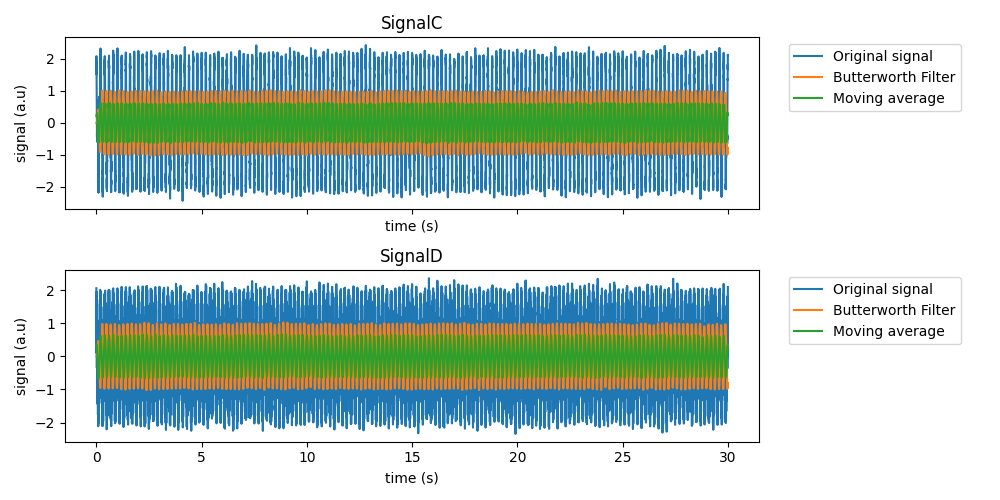

In [277]:
from scipy.signal import butter, lfilter

tstop = 30
time = np.linspace(0,tstop,tstop*1000)
dt=time[1]-time[0]

def gensignalC(t):
    ff = 5  
    ff2 = 15
    return np.cos(2*np.pi*(ff) * t ) + 0.2*np.random.normal(loc=0, scale=0.7, size=len(t)) + np.cos(2*np.pi*ff2*t)


signalC = gensignalC(time)

def gensignalD(t):
    ff = 5  
    ff2 = 60
    return np.cos(2*np.pi*(ff) * t ) + 0.2*np.random.normal(loc=0, scale=0.7, size=len(t)) + np.cos(2*np.pi*ff2*t)


signalD = gensignalD(time)


#Filter with Butterworth filter
def filter_butterworth(signal, dt, type = 'low', cutoff = 7):
    b, a = butter(N = 5, Wn = cutoff, btype = type, analog = False, fs = 1/dt)
    filtered_signal_butterworth = lfilter(b, a, signal)

    return filtered_signal_butterworth

#Filter with moving-average 
def filter_moving_average(signal, window_size = 100):
    return np.convolve(signal, np.ones(window_size) / window_size, mode='same')


dt = time[1]-time[0]
signalC_filtered_butter = filter_butterworth(signalC, dt)
signalC_filtered_ma = filter_moving_average(signalC)

signalD_filtered_butter = filter_butterworth(signalD, dt)
signalD_filtered_ma = filter_moving_average(signalD)


fig, ax = plt.subplots(2, 1, figsize = (10,5), sharex = True)
ax[0].plot(time, signalC, label = 'Original signal')
ax[0].plot(time, signalC_filtered_butter, label = 'Butterworth Filter')
ax[0].plot(time, signalC_filtered_ma, label = 'Moving average')
ax[0].set_xlabel('time (s)')
ax[0].set_ylabel('signal (a.u)')
ax[0].set_title('SignalC')
ax[0].legend(loc=1, bbox_to_anchor = (1.3, 1))

ax[1].plot(time, signalD, label = 'Original signal')
ax[1].plot(time, signalD_filtered_butter, label = 'Butterworth Filter')
ax[1].plot(time, signalD_filtered_ma, label = 'Moving average')
ax[1].set_xlabel('time (s)')
ax[1].set_ylabel('signal (a.u)')
ax[1].set_title('SignalD')
ax[1].legend(loc=1, bbox_to_anchor = (1.3, 1))



plt.tight_layout()

## Windowing
***Demonstration:*** Observing the effect of windowing. Substitue N by 1000 or 1024. See what happens and comment.

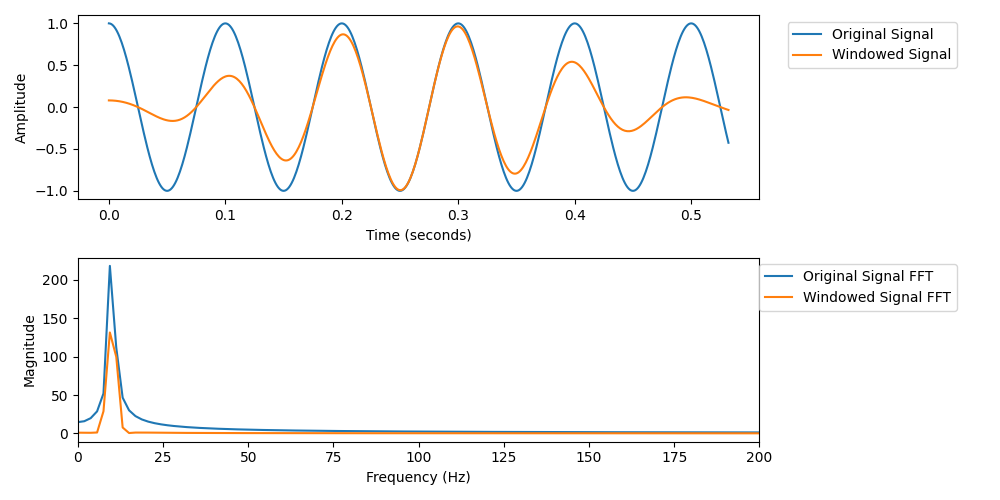

In [299]:
import numpy as np
import matplotlib.pyplot as plt

# Parameters
fs = 1000  # Sampling frequency in Hz
f = 10  # Frequency of the cosine wave in Hz
N = 533  # Number of samples

# Time vector
t = np.arange(N) / fs

# Generate the cosine signal
cosine_signal = np.cos(2 * np.pi * f * t)

# Apply a Hamming window
hamming_window = np.hamming(N)
windowed_signal = cosine_signal * hamming_window

# Perform the DFT
cosine_signal_fft = np.fft.fft(cosine_signal)
windowed_signal_fft = np.fft.fft(windowed_signal)

# Frequency vector
freqs = np.fft.fftfreq(N, 1/fs)

# Plot the original and windowed signal
fig, ax = plt.subplots(2, 1, figsize = (10,5))

ax[0].plot(t, cosine_signal, label='Original Signal')
ax[0].plot(t, windowed_signal, label='Windowed Signal')
ax[0].set_xlabel('Time (seconds)')
ax[0].set_ylabel('Amplitude')
ax[0].legend(loc = 1, bbox_to_anchor = (1.3, 1))

# Plot the magnitude spectrum
ax[1].plot(freqs[:N//2], np.abs(cosine_signal_fft[:N//2]), label='Original Signal FFT')
ax[1].plot(freqs[:N//2], np.abs(windowed_signal_fft[:N//2]), label='Windowed Signal FFT')
ax[1].set_xlabel('Frequency (Hz)')
ax[1].set_ylabel('Magnitude')
ax[1].legend(loc = 1, bbox_to_anchor = (1.3, 1))
ax[1].set_xlim(0, 200)

plt.tight_layout()
plt.show()